In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
fs = pd.read_csv("output/feasibility_study.csv")

conf = pd.read_excel("confounders.xlsx", header=0, index_col=0)
conf.columns = ["miner", "file", "n_base", "n_res", "n_alt_util", "n_confounders"]
conf["file"] = conf["file"].str.removesuffix(".exs")

df = fs.merge(conf[["file", "n_confounders"]], on="file", how="left")

count_cols = ["n_cases", "n_executions", "n_decision_rows", "n_choice_sets", "n_transitions_fitted", "n_confounders"]
time_cols  = ["t_util_s", "t_dml_s", "t_forest_s", "t_backdoor_s"]

for c in count_cols + time_cols:
    df[c] = pd.to_numeric(df[c], errors="coerce")

print(f"Rows total: {len(df)}  |  rows with n_confounders: {df['n_confounders'].notna().sum()}")
df[count_cols + time_cols].describe()

Rows total: 23  |  rows with n_confounders: 18


,n_cases,n_executions,n_decision_rows,n_choice_sets,n_transitions_fitted,n_confounders,t_util_s,t_dml_s,t_forest_s,t_backdoor_s
count,23.000000,23.000000,23.000000,23.000000,23.000000,18.000000,23.000000,23.000000,23.000000,23.000000
mean,10714.086957,115460.260870,73354.347826,60.695652,496.782609,447.611111,7.005949,72.722609,1217.839043,3146.107087
std,13908.341597,124442.130989,71551.667759,102.367624,947.076264,501.984783,11.261117,123.165050,1812.064135,7083.081310
min,645.000000,2994.000000,2539.000000,1.000000,5.000000,76.000000,0.081573,0.271000,9.985000,33.528000
25%,914.500000,25157.500000,23448.500000,1.500000,8.500000,131.500000,0.991624,1.328000,43.036000,211.627500
50%,7554.000000,71833.000000,44956.000000,6.000000,12.000000,203.500000,2.100511,3.392000,239.168000,486.805000
75%,13918.500000,147063.500000,118509.000000,48.500000,57.000000,597.000000,8.658526,109.699500,1751.069000,3059.110500
max,42995.000000,473688.000000,260453.000000,273.000000,2791.000000,1478.000000,50.222315,439.989000,7145.949000,33695.816000


In [3]:
# Pairwise Pearson correlation: rows = times, columns = counts
corr = pd.DataFrame(
    {count: {time: df[[count, time]].dropna().corr().loc[count, time]
             for time in time_cols}
     for count in count_cols},
    index=time_cols
)[count_cols]

corr

,n_cases,n_executions,n_decision_rows,n_choice_sets,n_transitions_fitted,n_confounders
t_util_s,0.816265,0.919349,0.836999,-0.258062,-0.260525,-0.205598
t_dml_s,-0.351318,-0.261665,-0.201661,0.873269,0.889014,0.744316
t_forest_s,-0.135956,0.042774,0.023333,0.468876,0.482970,0.570094
t_backdoor_s,-0.078658,0.060535,0.048789,-0.010540,-0.017150,0.712682


In [5]:
corr.to_csv('correlations.csv')

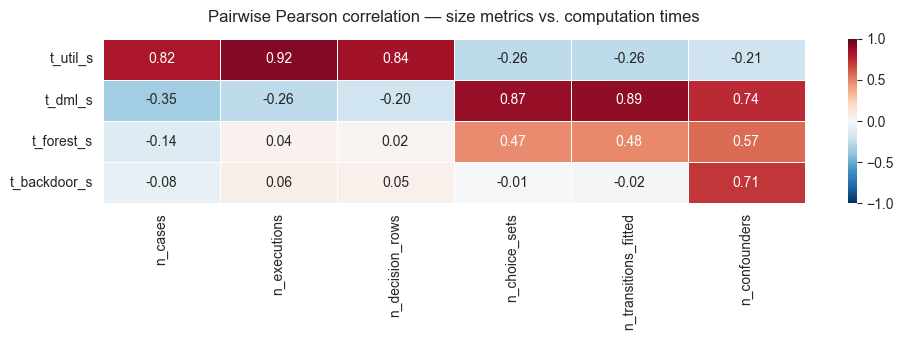

Saved → output/correlation_matrix.pdf


In [4]:
fig, ax = plt.subplots(figsize=(10, 3.5))
sns.heatmap(
    corr,
    annot=True, fmt=".2f",
    vmin=-1, vmax=1, center=0,
    cmap="RdBu_r",
    linewidths=0.5,
    ax=ax,
)
ax.set_title("Pairwise Pearson correlation — size metrics vs. computation times", pad=12)
ax.set_xlabel("")
ax.set_ylabel("")
plt.tight_layout()
plt.savefig("output/correlation_matrix.pdf", bbox_inches="tight")
plt.show()
print("Saved → output/correlation_matrix.pdf")